# Sesión 2 · Variables categóricas y numéricas
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Ana Paula Moreno, David Tinoco Romero, Alejandro Vázquez, Emilio Torres, Emilio Páez de la Mora |
| **Fecha** | 21-08-26 |
| **Objetivo** | Analizar las variables categóricas y numéricas de House Prices: distribución, cardinalidad, tendencia central, skewness, outliers y correlación con el target. |

---

> Usamos el mismo `train.csv` que descargaron en la sesión 1. Si no lo tienen, revisen las instrucciones de descarga en el notebook de la sesión anterior o del `README.md`.

In [1]:
from os import path
from matplotlib.path import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
    

DATA = Path("..")/"data"
df = pd.read_csv(DATA/"train_tratamiento.csv")
print('Dataset cargado:', df.shape)

Dataset cargado: (1460, 81)


---
## PARTE 1

### 1.1 Categóricas · `value_counts()`

Antes de ver si una variable categórica se relaciona con el target, hay que saber cómo está distribuida ¿está balanceada o hay categorías dominantes?

In [2]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [3]:
conteo = df['Neighborhood'].value_counts()
porcentaje = df['Neighborhood'].value_counts(normalize=True) * 100

resumen_barrios = pd.DataFrame({'casas': conteo, 'porcentaje': porcentaje.round(1)})
print(resumen_barrios.head(5))

              casas  porcentaje
Neighborhood                   
NAmes           225        15.4
CollgCr         150        10.3
OldTown         113         7.7
Edwards         100         6.8
Somerst          86         5.9


In [4]:
print(f"Top 3 barrios: {conteo.head(3).sum()} casas ({porcentaje.head(3).sum():.1f}% del dataset)")
print(f"Barrios con menos de 15 casas: {(conteo < 15).sum()}")

Top 3 barrios: 488 casas (33.4% del dataset)
Barrios con menos de 15 casas: 3


De los 25 vecindarios, la distribución está bastante desbalanceada: `NAmes` concentra
225 casas (15.4% del dataset) y los tres primeros (`NAmes`, `CollgCr`, `OldTown`)
suman 488, o sea un tercio de las 1,460 observaciones. En el otro extremo hay una cola
larga de barrios diminutos: `Blueste` con 2 casas, `NPkVill` con 9 y `Veenker` con 11.

Esto tiene dos consecuencias prácticas. Primero, cualquier estadístico calculado sobre
los barrios pequeños (media, mediana) es muy inestable: con 2 observaciones no se puede
concluir nada. Segundo, si convertimos `Neighborhood` a variables dummy generaríamos 25
columnas, varias con casi puros ceros. Conviene agrupar los barrios con menos de ~15
casas en una categoría "Otros" antes de modelar.

### 1.2 Relación con el target. `groupby()` + `.mean()`

¿Cambia el precio promedio según el vecindario?

In [5]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(0)

Neighborhood
NoRidge    335295.0
NridgHt    316271.0
StoneBr    310499.0
Timber     242247.0
Veenker    238773.0
Somerst    225380.0
ClearCr    212565.0
Crawfor    210625.0
CollgCr    197966.0
Blmngtn    194871.0
Gilbert    192855.0
NWAmes     189050.0
SawyerW    186556.0
Mitchel    156270.0
NAmes      145847.0
NPkVill    142694.0
SWISU      142591.0
Blueste    137500.0
Sawyer     136793.0
OldTown    128225.0
Edwards    128220.0
BrkSide    124834.0
BrDale     104494.0
IDOTRR     100124.0
MeadowV     98576.0
Name: SalePrice, dtype: float64

Las diferencias entre vecindarios son de decenas de miles de dólares. `Neighborhood` sí parece tener relación con `SalePrice`. Vale la pena verlo también con un boxplot para ver la distribución completa, no solo el promedio.

### 1.3 Boxplot por categoría

El boxplot muestra la distribución completa del target dentro de cada grupo: mediana, dispersión y outliers, no solo el promedio.

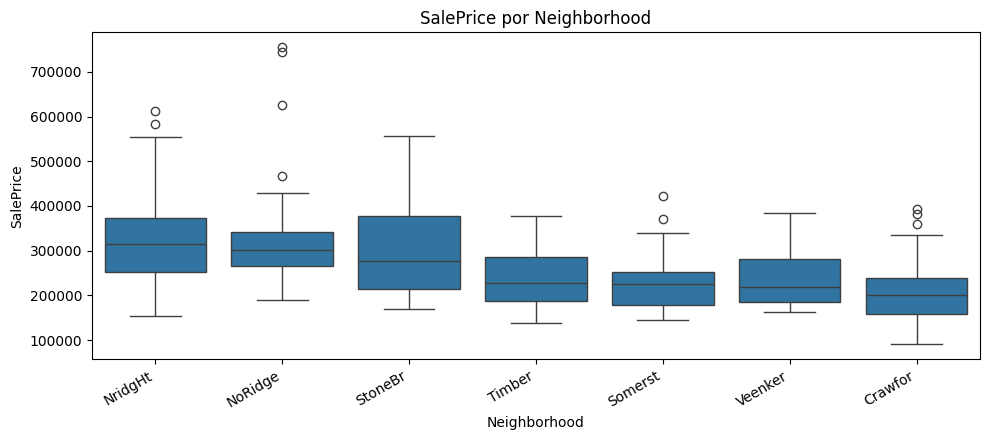

In [6]:
top_barrios = df.groupby('Neighborhood')['SalePrice'].median().nlargest(7).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df['Neighborhood'].isin(top_barrios)],
            x='Neighborhood', y='SalePrice', order=top_barrios, ax=ax)
ax.set_title('SalePrice por Neighborhood')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [7]:
top_barrios = df.groupby('Neighborhood')['SalePrice'].median().nlargest(7).index
sub = df[df['Neighborhood'].isin(top_barrios)]

resumen_top = sub.groupby('Neighborhood')['SalePrice'].agg(['count', 'median'])
resumen_top['Q1'] = sub.groupby('Neighborhood')['SalePrice'].quantile(0.25)
resumen_top['Q3'] = sub.groupby('Neighborhood')['SalePrice'].quantile(0.75)
resumen_top['IQR'] = resumen_top['Q3'] - resumen_top['Q1']

print(resumen_top.loc[top_barrios].round(0))

              count    median        Q1        Q3       IQR
Neighborhood                                               
NridgHt          77  315000.0  253293.0  374000.0  120707.0
NoRidge          41  301500.0  265000.0  341000.0   76000.0
StoneBr          25  278000.0  213500.0  377426.0  163926.0
Timber           38  228475.0  186900.0  286116.0   99216.0
Somerst          86  225500.0  177975.0  252920.0   74944.0
Veenker          11  218000.0  184250.0  282000.0   97750.0
Crawfor          51  200624.0  159250.0  239000.0   79750.0


In [8]:
print(f"\nCasas graficadas: {len(sub)} de {len(df)} ({len(sub)/len(df)*100:.1f}%)")


Casas graficadas: 329 de 1460 (22.5%)


In [9]:
barrio = 'NoRidge'
precios = df[df['Neighborhood'] == barrio]['SalePrice']

q1, q3 = precios.quantile(0.25), precios.quantile(0.75)
lim_sup_barrio = q3 + 1.5 * (q3 - q1)
bigote = precios[precios <= lim_sup_barrio].max()

print(f"{barrio}: bigote superior = {bigote:,.0f}")
print(f"Outliers: {sorted(precios[precios > lim_sup_barrio].values)}")

NoRidge: bigote superior = 430,000
Outliers: [np.int64(466500), np.int64(625000), np.int64(745000), np.int64(755000)]


Las medianas del top 7 **no** son parecidas: van de $315,000 (`NridgHt`) a $200,624
(`Crawfor`), unos $114,000 de diferencia dentro de un grupo que ya está preseleccionado
como el más caro. Se distinguen tres bloques:

- `NridgHt` ($315,000), `NoRidge` ($301,500) y `StoneBr` ($278,000) claramente arriba.
- `Timber` ($228,475), `Somerst` ($225,500) y `Veenker` ($218,000) en un escalón medio.
- `Crawfor` ($200,624) abajo del grupo.

El ancho de las cajas también dice algo. `StoneBr` tiene el IQR más amplio ($213,500 a
$377,426): es un barrio caro pero muy heterogéneo. `Somerst`, en cambio, tiene una caja
angosta ($177,975 a $252,920) con 86 casas: es un barrio grande y homogéneo, más fácil
de predecir.

Todos los vecindarios tienen outliers únicamente hacia arriba, nunca hacia abajo.
Es la primera señal del sesgo positivo de `SalePrice`, que aparece también dentro de
cada grupo y no solo en la distribución global. `NoRidge` es el caso extremo, con cuatro casas por encima de su bigote superior ($430,000), dos de ellas de $745,000 y $755,000.

Dos precauciones al leer esta gráfica:

1. Solo muestra 329 casas de 1,460 (22.5%), porque filtramos el top 7 por mediana.
   No es una vista del dataset completo, es un acercamiento a la parte cara.
2. `Veenker` tiene apenas 11 casas y `StoneBr` 25. Sus medianas y sus cajas son mucho
   menos confiables que las de `Somerst` (86) o `NridgHt` (77), aunque en la gráfica
   se vean igual de grandes.

### 1.4 Tendencia central y dispersión

In [10]:
print(f"Media:   {df['SalePrice'].mean():,.0f}")
print(f"Mediana: {df['SalePrice'].median():,.0f}")
print(f"Std:     {df['SalePrice'].std():,.0f}")
print(f"Rango:   {df['SalePrice'].min():,.0f} - {df['SalePrice'].max():,.0f}")

Media:   180,921
Mediana: 163,000
Std:     79,443
Rango:   34,900 - 755,000


In [11]:
media = df['SalePrice'].mean()
mediana = df['SalePrice'].median()
std = df['SalePrice'].std()

print(f"Media - Mediana:      {media - mediana:,.0f}  ({(media-mediana)/mediana*100:.1f}%)")
print(f"Coef. de variación:   {std/media*100:.1f}%")
print(f"Razón max/min:        {df['SalePrice'].max()/df['SalePrice'].min():.1f} veces")

Media - Mediana:      17,921  (11.0%)
Coef. de variación:   43.9%
Razón max/min:        21.6 veces


La media ($180,921) es mayor que la mediana ($163,000), una diferencia de $17,921
(11%). Segunda señal de sesgo positivo: hay casas caras jalando la media hacia arriba
mientras la mediana se queda anclada al centro real de los datos.

La desviación estándar ($79,443) equivale al 44% de la media, o sea una dispersión
enorme. Y el rango va de $34,900 a $755,000: la casa más cara vale 21.6 veces la más
barata. Esto anticipa un problema para un modelo lineal, porque un error de $20,000 es
catastrófico en una casa de $35,000 y despreciable en una de $755,000. Es un argumento
más a favor de modelar `log(SalePrice)` en lugar de `SalePrice`.

### 1.5 Skewness

In [12]:
print(f"SalePrice skew: {df['SalePrice'].skew():.2f}")
print(f"GrLivArea skew: {df['GrLivArea'].skew():.2f}")

SalePrice skew: 1.88
GrLivArea skew: 1.37


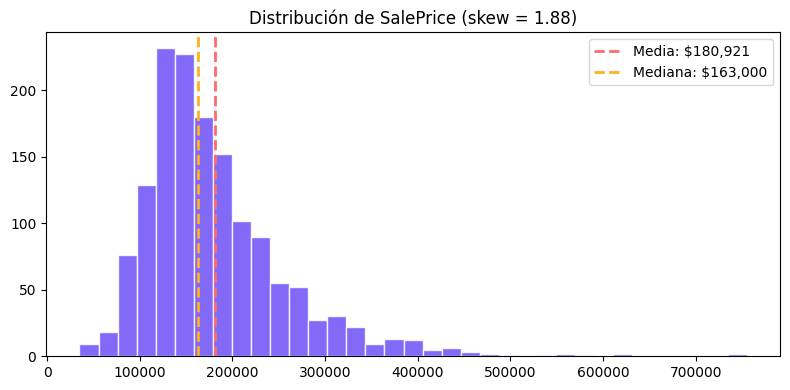

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['SalePrice'], bins=35, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2, linestyle='--',
           label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2, linestyle='--',
           label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax.set_title(f"Distribución de SalePrice (skew = {df['SalePrice'].skew():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
print(f"SalePrice skew: {df['SalePrice'].skew():.2f}  ->  con log1p: {np.log1p(df['SalePrice']).skew():.2f}")
print(f"GrLivArea skew: {df['GrLivArea'].skew():.2f}  ->  con log1p: {np.log1p(df['GrLivArea']).skew():.2f}")

SalePrice skew: 1.88  ->  con log1p: 0.12
GrLivArea skew: 1.37  ->  con log1p: -0.01


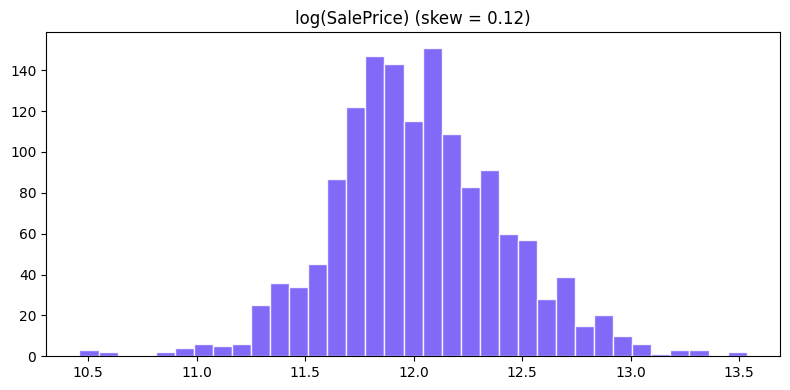

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(df['SalePrice']), bins=35, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.set_title(f"log(SalePrice) (skew = {np.log1p(df['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.show()

`SalePrice` tiene skew = 1.88 y `GrLivArea` skew = 1.37. **Las dos superan |γ| > 1**,
así que ambas tienen sesgo positivo fuerte por el mismo criterio; `GrLivArea` es menos
sesgada, no simétrica.

El histograma lo confirma: la moda está alrededor de $130k–$150k, la caída hacia la
izquierda es abrupta (ninguna casa por debajo de $34,900) y hacia la derecha hay una
cola larga y delgada que se estira hasta $755,000. Las dos líneas punteadas hacen
visible el efecto: la media queda a la derecha de la mediana precisamente porque esa
cola la arrastra.

Si aplicamos `np.log1p()`, el skew de `SalePrice` baja de 1.88 a 0.12 y el de
`GrLivArea` de 1.37 a -0.01, prácticamente normales. Esa es la transformación estándar
para este dataset.

### 1.6 Outliers · Regla de Tukey (1.5 × IQR)

In [16]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['GrLivArea'] < lim_inf) | (df['GrLivArea'] > lim_sup)]

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Límites: [{lim_inf:.0f}, {lim_sup:.0f}]')
print(f'Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Q1=1130  Q3=1777  IQR=647
Límites: [159, 2748]
Outliers encontrados: 31 (2.1%)


In [17]:
print(f"Outliers por debajo de {lim_inf:.0f}: {(df['GrLivArea'] < lim_inf).sum()}")
print(f"Outliers por encima de {lim_sup:.0f}: {(df['GrLivArea'] > lim_sup).sum()}")

Outliers por debajo de 159: 0
Outliers por encima de 2748: 31


In [18]:
print(f"Precio promedio outliers: {outliers['SalePrice'].mean():,.0f}")
print(f"Precio promedio resto:    {df.drop(outliers.index)['SalePrice'].mean():,.0f}")

Precio promedio outliers: 374,855
Precio promedio resto:    176,714


In [19]:
print(outliers.nlargest(4, 'GrLivArea')[
    ['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood', 'SaleCondition']
])

      GrLivArea  SalePrice  OverallQual Neighborhood SaleCondition
1298       5642     160000           10      Edwards       Partial
523        4676     184750           10      Edwards       Partial
1182       4476     745000           10      NoRidge       Abnorml
691        4316     755000           10      NoRidge        Normal


Con Q1 = 1,130 y Q3 = 1,777 el IQR es 647, y los límites de Tukey quedan en
[159, 2748]. Se detectaron 31 outliers, el 2.1% del dataset, **todos por el lado
superior**: ninguna casa cae por debajo del límite inferior, lo cual es consistente
con el sesgo positivo que ya vimos.

El caso más extremo es una casa de 5,642 ft², más del doble del límite superior.
Vale la pena mirar esas casas antes de decidir qué hacer con ellas: en promedio se
vendieron en $374,855 contra $176,714 del resto, así que la mayoría son casas grandes
y caras, es decir, outliers legítimos que no hay que borrar.

Pero hay dos excepciones sospechosas: las dos casas más grandes del dataset
(5,642 y 4,676 ft², ambas con `OverallQual` = 10 en `Edwards`) se vendieron en solo
$160,000 y $184,750. Rompen por completo la relación área-precio. La columna
`SaleCondition` lo explica: las dos son `Partial`, es decir ventas de casas que aún
no estaban terminadas al momento de la operación. En contraste, la casa de $755,000
en `NoRidge` es `Normal`, o sea un outlier legítimo que sí refleja el mercado. Estas
dos son las observaciones que suelen eliminarse en este dataset porque distorsionan
cualquier regresión lineal.

Conclusión: no conviene borrar los 31 outliers en bloque. Los que rompen la lógica del
resto de las variables son los que hay que revisar.

### 1.7 Correlación con el target

In [20]:
num_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'LotFrontage']
corr = df[num_cols].corr()

print(corr['SalePrice'].sort_values(ascending=False).round(2))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
YearBuilt      0.52
LotFrontage    0.35
Name: SalePrice, dtype: float64


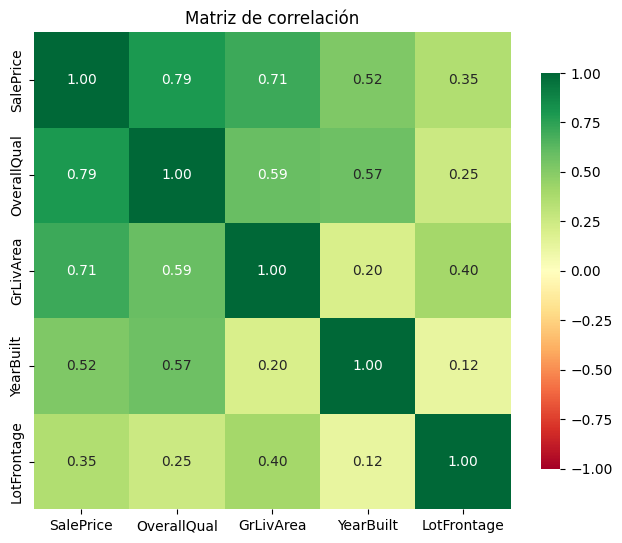

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [22]:
nulos = df[num_cols].isna().sum()
print(pd.DataFrame({'nulos': nulos, 'porcentaje': (nulos/len(df)*100).round(1)}))

             nulos  porcentaje
SalePrice        0         0.0
OverallQual      0         0.0
GrLivArea        0         0.0
YearBuilt        0         0.0
LotFrontage    259        17.7


`OverallQual` (0.79) y `GrLivArea` (0.71) son las más correlacionadas con `SalePrice`.
Que la calidad general encabece la lista tiene sentido: es una calificación de 1 a 10
que ya resume acabados, materiales y estado, así que concentra información que en otras
columnas está repartida.

`YearBuilt` (0.52) muestra una relación moderada, esperable porque las casas nuevas
tienden a valer más. `LotFrontage` (0.35) es la más débil de las cinco: es una relación
lineal real pero pequeña, no inexistente. Además tiene 259 valores nulos (17.7% del
dataset), así que antes de descartarla habría que decidir cómo imputarlos, ya que esos
faltantes también afectan el cálculo de la correlación.

En el heatmap se ve algo que la lista sola no muestra: `OverallQual` y `GrLivArea`
correlacionan 0.59 **entre ellas**, y `OverallQual` con `YearBuilt` 0.57. No son
predictores independientes; parte de la información que aportan se traslapa. Por eso
no basta con ordenar por correlación con el target, hay que revisar también la
correlación entre predictores antes de elegir con cuáles quedarse.

Un detalle sobre el método: `.corr()` calcula Pearson, que solo mide relación **lineal**.
Una correlación baja no descarta una relación no lineal. Y `OverallQual` es en realidad
una variable ordinal (1 a 10), no continua, así que su Pearson debe leerse con cautela
aunque sea el más alto de la tabla.

---
## PARTE 2

*A partir de aquí trabajan solos (en equipo). Completen las celdas de código y respondan en las celdas de interpretación.*

**Entregable:** este notebook, con todas las celdas ejecutadas y las interpretaciones completadas.

> Documentación oficial de pandas: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html).

### 2.1 Tabla de contingencia · `pd.crosstab()`

`pd.crosstab()` no se explicó en detalle en la presentación, búsquenla en la documentación de pandas antes de usarla.

Primero, creamos una categoría de precio a partir de `SalePrice` (ya que `crosstab` funciona mejor entre dos variables categóricas):

In [23]:
# Creamos una categoría binaria a partir de la mediana
mediana = df['SalePrice'].median()
df['CategoriaPrecio'] = np.where(df['SalePrice'] >= mediana, 'Caro', 'Económico')

df[['SalePrice', 'CategoriaPrecio']].head()

,SalePrice,CategoriaPrecio
0,208500,Caro
1,181500,Caro
2,223500,Caro
3,140000,Económico
4,250000,Caro


In [24]:
# Posteriormente se crea una tabla de contingencia entre CentralAir y CategoriaPrecio
contingency_table = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'])
print(contingency_table)

CategoriaPrecio  Caro  Económico
CentralAir                      
N                   7         88
Y                 725        640


In [25]:
# Con normalize='index' obtenemos proporciones por fila en vez de conteos
contingency_table = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'], normalize='index')
print(contingency_table)


CategoriaPrecio      Caro  Económico
CentralAir                          
N                0.073684   0.926316
Y                0.531136   0.468864


In [26]:
print(f"Con aire central: {(df['CentralAir']=='Y').sum()} casas ({(df['CentralAir']=='Y').mean()*100:.1f}%)")
print(f"Sin aire central: {(df['CentralAir']=='N').sum()} casas ({(df['CentralAir']=='N').mean()*100:.1f}%)")

Con aire central: 1365 casas (93.5%)
Sin aire central: 95 casas (6.5%)


**Interpretación:**

*¿Las casas con aire acondicionado central (`CentralAir = 'Y'`) tienden más a estar en la categoría 'Caro'? ¿Qué proporción de las casas sin aire acondicionado caen en cada categoría?*

Con `normalize='index'` cada renglón suma 1, así que los porcentajes se leen **dentro
de cada categoría de CentralAir**, no dentro de cada categoría de precio.

- De las 95 casas **sin** aire central (`N`), solo el 7.4% (7 casas) cae en "Caro" y
  el 92.6% (88 casas) en "Económico".
- De las 1,365 casas **con** aire central (`Y`), el 53.1% es "Caro" y el 46.9% es
  "Económico".

Sí hay relación: tener aire central multiplica por más de 7 la proporción de casas
caras. Pero la conclusión útil es asimétrica. Saber que una casa **no** tiene aire
central casi garantiza que está por debajo de la mediana; saber que **sí** lo tiene es
casi un volado (53/47). Además, `CentralAir = 'Y'` describe al 93.5% del dataset, así
que la variable es informativa sobre todo por su ausencia: funciona como bandera de
casa antigua o de bajo estándar, más que como indicador de casa cara.

### 2.2 Cardinalidad de todas las variables categóricas

Revisen la cardinalidad de **todas** las columnas categóricas del dataset, no solo `Neighborhood`.

In [27]:
#Revisen la cardinalidad de **todas** las columnas categóricas del dataset, no solo `Neighborhood`.

nunique_values = df.select_dtypes(include=['object', 'string']).nunique()
print(nunique_values)

MSZoning            5
Street              2
Alley               2
LotShape            4
LandContour         4
Utilities           2
LotConfig           5
LandSlope           3
Neighborhood       25
Condition1          9
Condition2          8
BldgType            5
HouseStyle          8
RoofStyle           6
RoofMatl            8
Exterior1st        15
Exterior2nd        16
MasVnrType          3
ExterQual           4
ExterCond           5
Foundation          6
BsmtQual            4
BsmtCond            4
BsmtExposure        4
BsmtFinType1        6
BsmtFinType2        6
Heating             6
HeatingQC           5
CentralAir          2
Electrical          5
KitchenQual         4
Functional          7
FireplaceQu         5
GarageType          6
GarageFinish        3
GarageQual          5
GarageCond          5
PavedDrive          3
PoolQC              3
Fence               4
MiscFeature         4
SaleType            9
SaleCondition       6
CategoriaPrecio     2
dtype: int64


In [28]:
len(df)

1460

In [29]:
cardinalidad = df.nunique().sort_values(ascending=False)
print(cardinalidad.head(5))
print(f"\nId: {df['Id'].nunique()} valores únicos en {len(df)} filas")

Id           1460
LotArea      1073
GrLivArea     861
BsmtUnfSF     780
1stFlrSF      753
dtype: int64

Id: 1460 valores únicos en 1460 filas


In [30]:
for col in ['Utilities', 'Street', 'CentralAir']:
    dominante = df[col].value_counts(normalize=True).iloc[0]
    print(f"{col:12s} valor dominante = {dominante*100:.1f}%")

Utilities    valor dominante = 99.9%
Street       valor dominante = 99.6%
CentralAir   valor dominante = 93.5%


**Interpretación:**

*¿Alguna columna tiene cardinalidad sospechosamente alta (cercana al número de filas)? ¿Qué columna del dataset es? ¿Qué se debería de hacer con esta?*


`df.select_dtypes(include='object')` solo revisa columnas de texto, y ahí la
cardinalidad máxima es `Neighborhood` con 25 categorías sobre 1,460 filas (1.7%),
seguida de `Exterior2nd` (16) y `Exterior1st` (15). Ninguna es sospechosa.

La columna que sí lo es no aparece en este output porque es numérica: **`Id`**, con
1,460 valores únicos en 1,460 filas, es decir 100% de cardinalidad. Es un identificador
de renglón, no una característica de la casa. Hay que eliminarla antes de modelar,
porque un modelo con suficiente capacidad puede memorizarla y sobreajustarse a ella.

El caso opuesto también conviene señalarlo: `Utilities` tiene solo 2 categorías, pero
1,459 de 1,460 casas son `AllPub`. Cardinalidad baja y varianza casi nula, así que
tampoco aporta información. Lo mismo con `Street` (1,454 de 1,460 son `Pave`).

Aclaración importante: cardinalidad alta no implica automáticamente eliminar. Si se
tratara de una variable real y no de un ID, la solución sería agrupar las categorías
raras en "Otros" o usar codificación por target, no descartarla.

### 2.3 Boxplot de dos variables categóricas adicionales

Elijan **dos** variables categóricas del dataset (distintas a `Neighborhood`) y grafiquen su boxplot contra `SalePrice`.

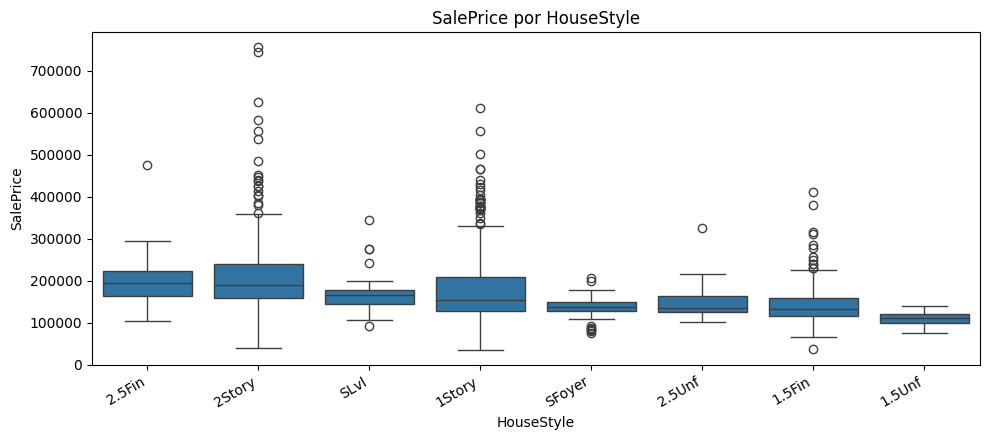

In [31]:
var_1 = 'HouseStyle'

orden_estilos = df.groupby(var_1)['SalePrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df[var_1].isin(orden_estilos)],
            x=var_1, y='SalePrice', order=orden_estilos, ax=ax)
ax.set_title(f'SalePrice por {var_1}')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

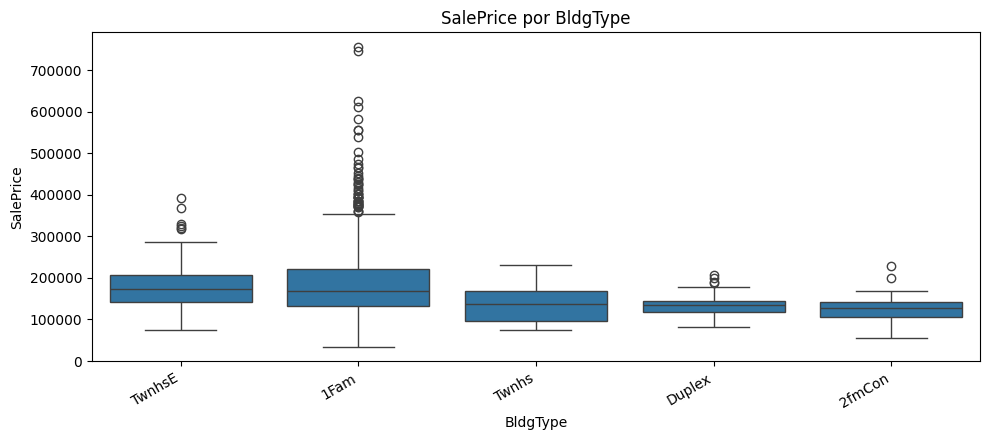

In [32]:
# Variable categórica 2
var_2 = 'BldgType'
top_tipos = df.groupby(var_2)['SalePrice'].median().nlargest(7).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df[var_2].isin(top_tipos)],
            x=var_2, y='SalePrice', order=top_tipos, ax=ax)
ax.set_title(f'SalePrice por {var_2}')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [33]:
def resumen_categorica(col):
    r = df.groupby(col)['SalePrice'].agg(['count', 'median'])
    r['Q1'] = df.groupby(col)['SalePrice'].quantile(0.25)
    r['Q3'] = df.groupby(col)['SalePrice'].quantile(0.75)
    r['%_dataset'] = (r['count'] / len(df) * 100).round(1)
    return r.sort_values('median', ascending=False).round(1)

In [34]:
print(resumen_categorica('HouseStyle'))

            count    median        Q1        Q3  %_dataset
HouseStyle                                                
2.5Fin          8  194000.0  164250.0  223750.0        0.5
2Story        445  190000.0  159500.0  240000.0       30.5
SLvl           65  164500.0  145000.0  178000.0        4.5
1Story        726  154750.0  127000.0  209350.0       49.7
SFoyer         37  135960.0  127500.0  148000.0        2.5
2.5Unf         11  133900.0  125000.0  163500.0        0.8
1.5Fin        154  132000.0  114625.0  159325.5       10.5
1.5Unf         14  111250.0   98175.0  120500.0        1.0


In [35]:
print(resumen_categorica('BldgType'))

          count    median        Q1        Q3  %_dataset
BldgType                                                
TwnhsE      114  172200.0  143187.5  207375.0        7.8
1Fam       1220  167900.0  131475.0  222000.0       83.6
Twnhs        43  137500.0   95750.0  168750.0        2.9
Duplex       52  135980.0  118375.0  145000.0        3.6
2fmCon       31  127500.0  106875.0  142500.0        2.1


**Interpretación:**

**HouseStyle sí tiene una relación clara con SalePrice.** El contraste más fuerte
está entre casas de 2 plantas y de 1 planta:

- `2Story` (445 casas): mediana $190,000, con el 50% central entre $159,500 y $240,000.
- `1Story` (726 casas): mediana $154,750, con el 50% central entre $127,000 y $209,350.

Son ~$35,000 de diferencia en la mediana (las de 2 plantas son 23% más caras) y toda
la caja de `2Story` está desplazada hacia arriba, no solo la línea central. Más abajo,
`1.5Fin` (154 casas) tiene mediana de $132,000 y `1.5Unf` de $111,250: las casas de
1.5 plantas con el segundo piso sin terminar son las más baratas del dataset. Entre el
estilo más caro y el más barato hay ~$80,000 de diferencia, no es un efecto despreciable.

Dos advertencias sobre lo que muestra la gráfica:

1. `2.5Fin` aparece en primer lugar (mediana $194,000) pero solo tiene **8 casas**.
   Su mediana no es confiable y no debe leerse como "el estilo más caro". Lo mismo pasa
   con `2.5Unf` (11 casas) y `1.5Unf` (14).
2. `2Story` y `1Story` tienen colas largas hacia arriba, con outliers de $400k a $750k,
   mientras que `SFoyer` y `SLvl` son cajas muy compactas. Esos dos estilos ocupan un
   rango de precio mucho más acotado.

**BldgType también separa, aunque con más traslape.** Se forman dos grupos:

- Arriba: `1Fam` (mediana $167,900) y `TwnhsE` ($172,200), prácticamente empatados.
- Abajo: `Twnhs` ($137,500), `Duplex` ($135,980) y `2fmCon` ($127,500), unos $30,000
  a $45,000 por debajo.

Lo interesante es que `1Fam` y `TwnhsE` tienen medianas casi iguales pero dispersiones
muy distintas: el IQR de `1Fam` va de $131,475 a $222,000 y el de `TwnhsE` de $143,188
a $207,375. Los townhouses son un producto más homogéneo; las casas unifamiliares
abarcan todo el rango del dataset, desde $34,900 hasta $755,000.

**Implicación para el modelo:** `BldgType` está muy desbalanceada (1,220 de 1,460 casas
son `1Fam`, el 83.6%), así que aporta poco: solo informa cuando la casa NO es
unifamiliar. `HouseStyle` sí vale la pena conservarla, agrupando los estilos con pocas
observaciones (`2.5Fin`, `2.5Unf`, `1.5Unf`) en una categoría "Otros" para que sus
medianas no distorsionen el análisis.

### 2.4 Skewness de todas las variables numéricas

Calculen el skewness de todas las columnas numéricas a la vez (no solo `SalePrice` y `GrLivArea`) y ordénenlas de mayor a menor sesgo.

In [36]:
numeric_cols = df.select_dtypes(include=np.number).columns
skewness_values = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness_values)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
G

In [37]:
sesgadas = skewness_values[skewness_values.abs() > 1]
print(f"Variables con |skew| > 1: {len(sesgadas)}")
print(f"Positivas: {(sesgadas > 1).sum()}   Negativas: {(sesgadas < -1).sum()}")
print(f"Skew más negativo: {skewness_values.min():.2f} ({skewness_values.idxmin()})")

Variables con |skew| > 1: 20
Positivas: 20   Negativas: 0
Skew más negativo: -0.65 (GarageYrBlt)


In [38]:
top_sesgadas = skewness_values.head(8).index

diagnostico = pd.DataFrame({
    'skew': skewness_values.head(8).round(2),
    'pct_ceros': (df[top_sesgadas] == 0).mean().round(3) * 100,
    'corr_SalePrice': df[top_sesgadas].corrwith(df['SalePrice']).round(3)
})
print(diagnostico)

               skew  pct_ceros  corr_SalePrice
MiscVal       24.48       96.4          -0.021
PoolArea      14.83       99.5           0.092
LotArea       12.21        0.0           0.264
3SsnPorch     10.30       98.4           0.045
LowQualFinSF   9.01       98.2          -0.026
KitchenAbvGr   4.49        0.1          -0.136
BsmtFinSF2     4.26       88.6          -0.011
ScreenPorch    4.12       92.1           0.111


In [39]:
print(f"LotArea: mediana={df['LotArea'].median():,.0f}  max={df['LotArea'].max():,.0f}  ceros={(df['LotArea']==0).sum()}")

LotArea: mediana=9,478  max=215,245  ceros=0


**Interpretación:**

*¿Qué variables tienen |skew| > 1? ¿Alguna las sorprendió?*


Hay **20** variables con |skew| > 1 y todas tienen sesgo positivo; ninguna llega a -1
(la más negativa es `GarageYrBlt` con -0.65). A nuestra lista original le faltaba
`LowQualFinSF` (skew = 9.01).

El sesgo extremo de las primeras no se debe a que sean características caras, sino a
que **casi todas valen cero**:

| Variable | Skew | % de casas en 0 |
|---|---|---|
| MiscVal | 24.48 | 96.4% |
| PoolArea | 14.83 | 99.5% |
| 3SsnPorch | 10.30 | 98.4% |
| LowQualFinSF | 9.01 | 98.2% |
| BsmtFinSF2 | 4.26 | 88.6% |

No son distribuciones sesgadas en el sentido habitual, son variables *cero-infladas*:
una montaña de ceros y unas pocas casas con valores grandes. Por eso el skew se dispara.

Y el sesgo alto **no** significa que suban el precio. `MiscVal` correlaciona -0.02 con
`SalePrice` y `PoolArea` apenas 0.09, es decir, prácticamente nada. Tener alberca no
predice el precio en este dataset porque solo 7 casas de 1,460 tienen alberca: no hay
suficientes observaciones para que el modelo aprenda algo.

La que sí sorprende es **`LotArea`** (skew = 12.21), porque no tiene ceros. Ahí el
sesgo viene de unos pocos terrenos enormes (hasta 215,245 ft²) contra una mediana de
9,478 ft². Ese es un sesgo real, corregible con una transformación logarítmica
(`np.log1p`), a diferencia de las cero-infladas, donde lo más razonable es convertirlas
en variables binarias del tipo "tiene alberca sí/no" o descartarlas.



### 2.5 Matriz de correlación completa

En la demo solo usamos 5 columnas numéricas. Ahora calculen la matriz de correlación con **todas** las columnas numéricas del dataset.

In [40]:
corr_all = df[numeric_cols].corr()
display(corr_all)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


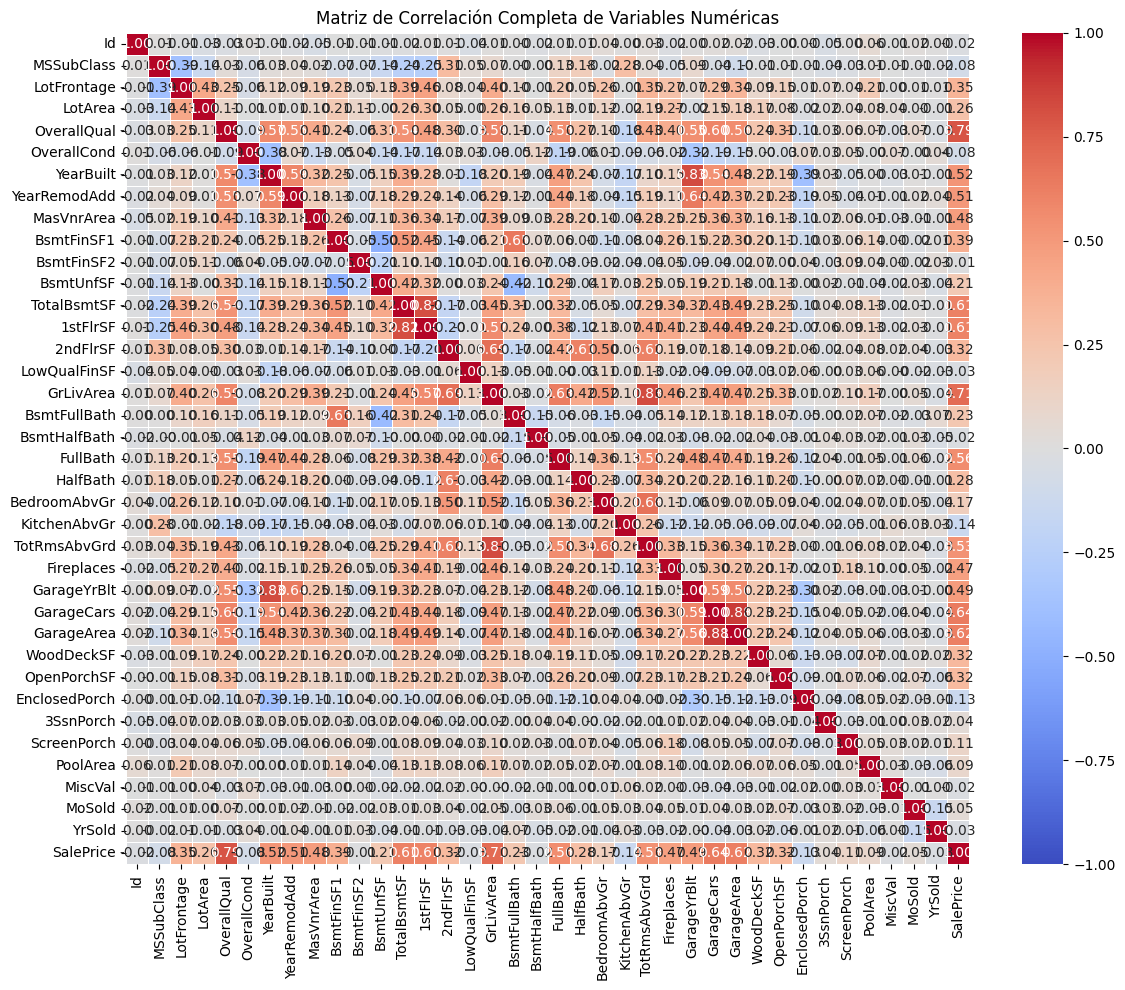

In [41]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=.5)
ax.set_title('Matriz de Correlación Completa de Variables Numéricas')
plt.tight_layout()
plt.show()

In [42]:
print(corr_all['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(6).round(3))

OverallQual    0.791
GrLivArea      0.709
GarageCars     0.640
GarageArea     0.623
TotalBsmtSF    0.614
1stFlrSF       0.606
Name: SalePrice, dtype: float64


In [43]:
candidatas = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
              'TotalBsmtSF', '1stFlrSF', 'TotRmsAbvGrd', 'YearBuilt']

display(corr_all.loc[candidatas, candidatas].round(2))

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,TotRmsAbvGrd,YearBuilt
OverallQual,1.00,0.59,0.60,0.56,0.54,0.48,0.43,0.57
GrLivArea,0.59,1.00,0.47,0.47,0.45,0.57,0.83,0.20
GarageCars,0.60,0.47,1.00,0.88,0.43,0.44,0.36,0.54
GarageArea,0.56,0.47,0.88,1.00,0.49,0.49,0.34,0.48
TotalBsmtSF,0.54,0.45,0.43,0.49,1.00,0.82,0.29,0.39
1stFlrSF,0.48,0.57,0.44,0.49,0.82,1.00,0.41,0.28
TotRmsAbvGrd,0.43,0.83,0.36,0.34,0.29,0.41,1.00,0.10
YearBuilt,0.57,0.20,0.54,0.48,0.39,0.28,0.10,1.00


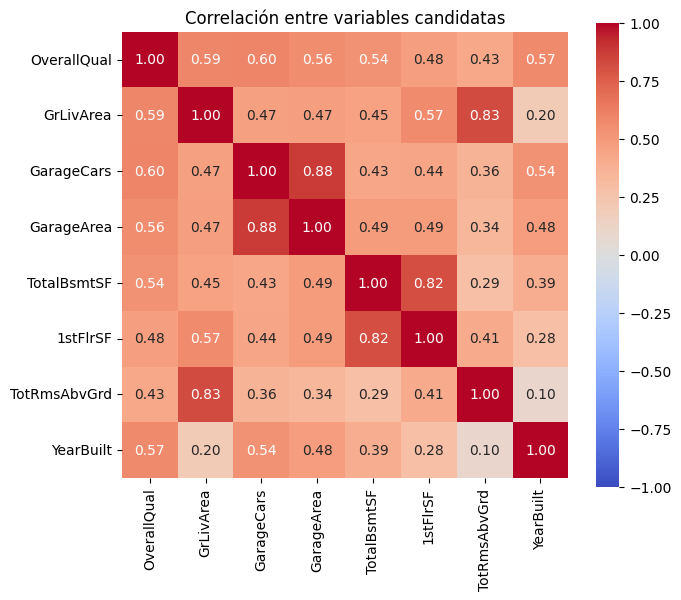

In [44]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_all.loc[candidatas, candidatas], annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlación entre variables candidatas')
plt.tight_layout()
plt.show()

**Interpretación:**

*¿Cuáles son las 3 variables más correlacionadas con SalePrice en el dataset completo? Según la estrategia de priorización de la presentación, ¿en qué variables se enfocarían primero si tuvieran que elegir solo 5 para seguir explorando?*


Las 3 variables más correlacionadas con `SalePrice` son `OverallQual` (0.79),
`GrLivArea` (0.71) y `GarageCars` (0.64). `TotalBsmtSF` queda en quinto lugar (0.61),
por detrás de `GarageArea` (0.62).

Para elegir 5 no basta con tomar el top 5, porque varias de esas variables miden lo
mismo entre sí (multicolinealidad). Revisando la matriz completa:

- `GarageCars` y `GarageArea` correlacionan 0.88 entre ellas: son la misma información
  (cajones vs. metros de cochera). Conviene quedarse con una sola.
- `TotalBsmtSF` y `1stFlrSF` correlacionan 0.82.
- `GrLivArea` y `TotRmsAbvGrd` correlacionan 0.83.

Nuestras 5: **OverallQual, GrLivArea, GarageCars, TotalBsmtSF y YearBuilt**.
Incluimos `YearBuilt` (0.52) aunque tiene menor correlación con el target porque aporta
información distinta (antigüedad) y correlaciona poco con `GrLivArea` (0.20), mientras
que `GarageArea` o `TotRmsAbvGrd` serían redundantes con las que ya elegimos.

---
## Resumen de hallazgos (conclusión del equipo)

| Pregunta | Respuesta del equipo |
|---|---|
| ¿`Neighborhood` parece influir en `SalePrice`? | Sí, la diferencia del neighborhood puede cambiar significativamente el precio de las casas
| ¿Cuál es la columna categórica con mayor cardinalidad (aparte de un ID)?| Neigborhood. Cuenta con 25 categorías.|
|¿`SalePrice` tiene sesgo? ¿Positivo o negativo, y qué tan fuerte| Positivo. La media es mayor que la mediana, generando este sesgo. Esto se debe principalmente a que existen un par de outliers que arrastran la media hacia arriba. El sesgo es fuerte.
| ¿Qué porcentaje de outliers encontraron en `GrLivArea`? | 2.1%
| ¿Cuáles son las 3 variables más correlacionadas con el target? | OverallQual (0.79), GrLivArea (0.71) y GarageCars (0.64)
| ¿Qué variable descartarían de entrada por baja correlación y baja variabilidad? | BsmtFinSF2: correlación de -0.011 (la más baja en valor absoluto de todo el dataset) y 88.6% de sus valores son cero. Entre las categóricas, Utilities por la misma razón: 1,459 de 1,460 casas tienen el mismo valor

In [45]:
correlaciones = corr_all['SalePrice'].drop('SalePrice')
print(correlaciones.abs().sort_values().head(3).round(3))
print(f"\nBsmtFinSF2: corr={correlaciones['BsmtFinSF2']:.3f}  ceros={(df['BsmtFinSF2']==0).mean()*100:.1f}%")

BsmtFinSF2      0.011
BsmtHalfBath    0.017
MiscVal         0.021
Name: SalePrice, dtype: float64

BsmtFinSF2: corr=-0.011  ceros=88.6%
